# EX 2 — Bidirectional RNN vs Feedforward Neural Network

**AI23531 Deep Learning Lab — Individual Experiment**

The code and the output below are preserved from the uploaded `Copy_of_deep_learning_lab.ipynb`.

Epoch 20/100, Loss: 0.00278
Epoch 40/100, Loss: 0.00229
Epoch 60/100, Loss: 0.00236
Epoch 80/100, Loss: 0.00200
Epoch 100/100, Loss: 0.00282
Epoch 20/100, Loss: 0.00304
Epoch 40/100, Loss: 0.00211
Epoch 60/100, Loss: 0.00163
Epoch 80/100, Loss: 0.00195
Epoch 100/100, Loss: 0.00075


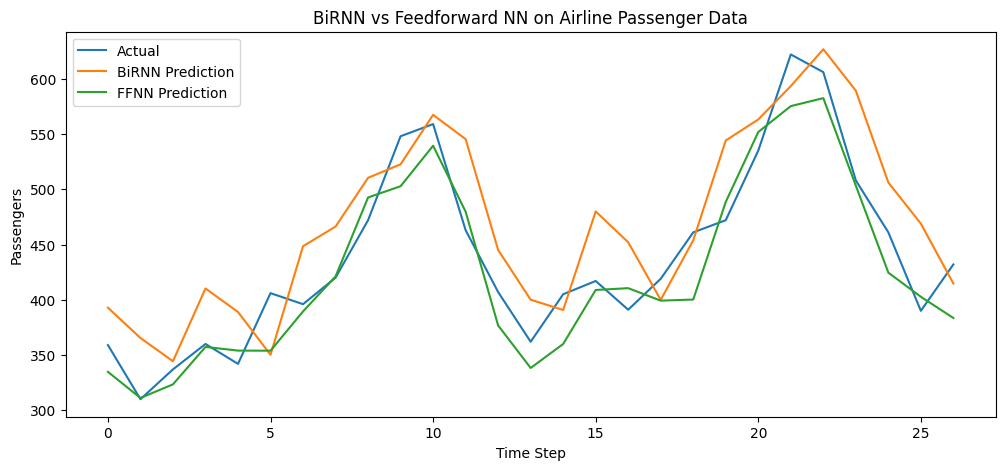

BiRNN MSE: 2207.002
FFNN MSE: 815.158


In [ ]:
import pandas as pd, numpy as np, torch, torch.nn as nn
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/refs/heads/master/monthly-airline-passengers.csv'
data = pd.read_csv(url, usecols=[1]).values.astype('float32')
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

SEQ_LEN = 10
X = np.array([data_scaled[i:i+SEQ_LEN] for i in range(len(data_scaled)-SEQ_LEN)])
y = np.array([data_scaled[i+SEQ_LEN] for i in range(len(data_scaled)-SEQ_LEN)])
n = int(len(X)*0.8)
X_train, X_test, y_train, y_test = X[:n], X[n:], y[:n], y[n:]

X_train_t, y_train_t = torch.tensor(X_train), torch.tensor(y_train)
X_test_t, y_test_t = torch.tensor(X_test), torch.tensor(y_test)
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=16, shuffle=True)

class BiRNN(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=1):
        super().__init__()
        self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden_size*2, 1)
    def forward(self, x):
        out, _ = self.rnn(x)
        return self.fc(out[:,-1,:])

class FeedforwardNN(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.fc1, self.relu, self.fc2 = nn.Linear(input_size,64), nn.ReLU(), nn.Linear(64,1)
    def forward(self, x):
        return self.fc2(self.relu(self.fc1(x.view(x.size(0),-1))))

def train_model(model, loader, epochs=100):
    crit, opt = nn.MSELoss(), torch.optim.Adam(model.parameters(), lr=0.01)
    model.train()
    for epoch in range(epochs):
        le = 0
        for seqs, targets in loader:
            opt.zero_grad()
            loss = crit(model(seqs), targets)
            loss.backward(); opt.step(); le += loss.item()
        if (epoch+1) % 20 == 0:
            print(f"Epoch {epoch+1}/{epochs}, Loss: {le/len(loader):.5f}")

def evaluate_model(model, X):
    model.eval()
    with torch.no_grad():
        return model(X).numpy()

birnn = BiRNN(); train_model(birnn, train_loader)
ffnn = FeedforwardNN(SEQ_LEN); train_model(ffnn, train_loader)
pred_birnn = evaluate_model(birnn, X_test_t)
pred_ffnn = evaluate_model(ffnn, X_test_t)

pred_birnn_inv = scaler.inverse_transform(pred_birnn)
pred_ffnn_inv = scaler.inverse_transform(pred_ffnn)
y_test_inv = scaler.inverse_transform(y_test)

plt.figure(figsize=(12,5))
plt.plot(y_test_inv, label='Actual')
plt.plot(pred_birnn_inv, label='BiRNN Prediction')
plt.plot(pred_ffnn_inv, label='FFNN Prediction')
plt.legend(); plt.title('BiRNN vs Feedforward NN on Airline Passenger Data')
plt.xlabel('Time Step'); plt.ylabel('Passengers'); plt.show()

print(f"BiRNN MSE: {mean_squared_error(y_test_inv, pred_birnn_inv):.3f}")
print(f"FFNN MSE: {mean_squared_error(y_test_inv, pred_ffnn_inv):.3f}")